# Trade Dependency Risk Analysis

>Which partner country does Japan depend on most for imports?

>How concentrated is that dependency?

>Is Japan's dependency getting better or worse over time?

In [1]:
# Setup 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# master_trade.csv is clean, standardized source
master = pd.read_csv("../data/processed/master_trade.csv")

print(f"Shape: {master.shape}")
print(f"Years: {sorted(master['year'].unique())}")
print(f"Reporters: {master['reporter'].unique()}")

Shape: (26951, 5)
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Reporters: <StringArray>
['Japan', 'China', 'Germany', 'USA', 'Rep. of Korea', 'United Kingdom']
Length: 6, dtype: str


### Japan bilaterall imports

In [12]:
# Why exclude 'World' partner:
# World row = Japan's total imports (summary)
# For dependency analysis we need indivisual partner rows
# We want to know: what % comes from china specifically?
# That question requires partner-level rows, not the total

japan_imports = master[
    (master['reporter'] == 'Japan') &
    (master['flow'] == 'Import') &
    (master['partner'] != 'World')
].copy()


# Why also get the world total separately:
# I use world row as the DENOMINATOR for dependency % 
# dependency% = imports_from_china / total_japan_imports
# total_japan_imports comes from the world row

japan_total_imports = master[
    (master['reporter'] == 'Japan') &
    (master['flow'] == 'Import') &
    (master['partner'] == 'World')
][['year', 'value_usd']].rename(columns={'value_usd': 'total_usd'})

print(f"Bilateral import rows: {len(japan_imports)}")
print(f"Total rows (World): {len(japan_total_imports)}")
print(f"\nSample partners: {japan_imports['partner'].unique()[:8]}")

Bilateral import rows: 2158
Total rows (World): 10

Sample partners: <StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
      'American Samoa',             'Andorra',              'Angola',
 'Antigua and Barbuda',          'Azerbaijan']
Length: 8, dtype: str


### Dependency % per partner per year

In [13]:
# WHY merge with total before calculating %:
# dependency% = partner_imports / total_imports × 100
# We need total_imports for each year as denominator
# Merging on 'year' aligns each partner row with
# that year's total — guarantees correct calculation

japan_imports = japan_imports.merge(
    japan_total_imports, on='year')

# WHY this formula:
# If Japan imports $168bn from China in 2023
# and total Japan imports = $752bn
# then China dependency = 168/752 × 100 = 22.4%
# This is the share of Japan's import supply
# that depends on one country

japan_imports['dependency_pct'] = (
    japan_imports['value_usd'] /
    japan_imports['total_usd'] * 100
).round(3)

print("Sample dependency calculation:")
sample = japan_imports[japan_imports['year']==2023].nlargest(
    5, 'dependency_pct')[['partner','value_usd',
                           'total_usd','dependency_pct']]
print(sample.to_string(index=False))

Sample dependency calculation:
             partner    value_usd    total_usd  dependency_pct
               China 1.680568e+11 7.517504e+11          22.355
                 USA 7.604403e+10 7.517504e+11          10.116
           Australia 6.453524e+10 7.517504e+11           8.585
United Arab Emirates 3.697184e+10 7.517504e+11           4.918
        Saudi Arabia 3.468264e+10 7.517504e+11           4.614


### Top 10 most depended-on partners (2023)

In [14]:
dep_2023 = (japan_imports[japan_imports['year'] == 2023]
            .nlargest(10, 'dependency_pct')[['partner', 'dependency_pct', 'value_usd']]
            .copy())

dep_2023['value_bn'] = dep_2023['value_usd'] / 1e9

print("Japan Import Dependency (2023):")
print(dep_2023[['partner', 'value_bn',
                'dependency_pct']].to_string(index=False))

Japan Import Dependency (2023):
             partner   value_bn  dependency_pct
               China 168.056752          22.355
                 USA  76.044028          10.116
           Australia  64.535238           8.585
United Arab Emirates  36.971839           4.918
        Saudi Arabia  34.682643           4.614
     Other Asia, nes  34.650802           4.609
       Rep. of Korea  30.239593           4.023
            Viet Nam  25.352011           3.372
            Thailand  24.322486           3.235
           Indonesia  24.101008           3.206


### Dependency Chart

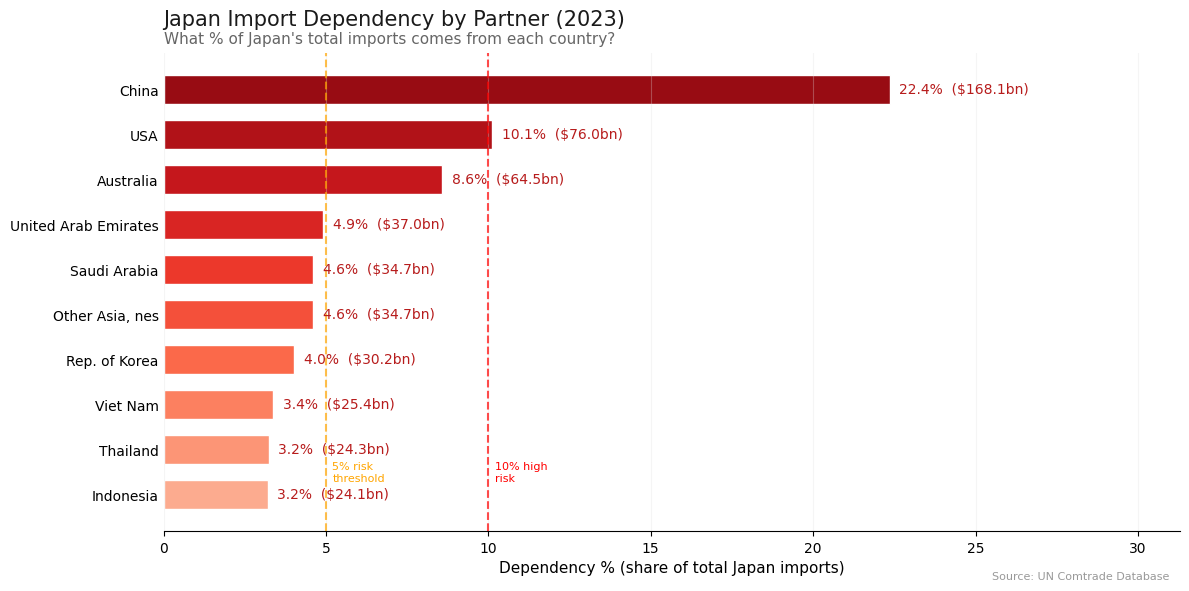

✓ Saved


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

dep_sorted = dep_2023.sort_values('dependency_pct')

# WHY color intensity by dependency level:
# Darker = more dangerous dependency
# Visual encoding of risk level — no legend needed

n = len(dep_sorted)
palette = plt.cm.Reds(np.linspace(0.3, 0.9, n))

bars = ax.barh(dep_sorted['partner'],
               dep_sorted['dependency_pct'],
               color=palette,
               edgecolor='white',
               height=0.65)

for bar, val, vbn in zip(bars,
                          dep_sorted['dependency_pct'],
                          dep_sorted['value_bn']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (${vbn:.1f}bn)',
            va='center', fontsize=10,
            color='#B71C1C', fontweight='500')

# WHY mark the 5% threshold line:
# Economists use 5% as a rule of thumb —
# any single partner above 5% = noteworthy dependency
# Above 10% = significant risk
# Above 20% = structural vulnerability

ax.axvline(x=5, color='orange', linestyle='--',
           alpha=0.7, linewidth=1.5)
ax.text(5.2, 0.3, '5% risk\nthreshold',
        fontsize=8, color='orange')

ax.axvline(x=10, color='red', linestyle='--',
           alpha=0.7, linewidth=1.5)
ax.text(10.2, 0.3, '10% high\nrisk',
        fontsize=8, color='red')

ax.set_title("Japan Import Dependency by Partner (2023)",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'What % of Japan\'s total imports comes from each country?',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel("Dependency % (share of total Japan imports)",
              fontsize=11)
ax.set_xlim(0, dep_sorted['dependency_pct'].max() * 1.4)
ax.tick_params(axis='y', length=0)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(True, alpha=0.3, axis='x', color='#E0E0E0')

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/import_dependency_2023.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

### China dependency trend over time

In [16]:
# Why track China specifically over 10 years:
# China is Japan's #1 dependency partner
# Is Japan reducing this dependency or increasing it?
# This trend tells us if Japan's diversification
# policy is actually working

china_dep = japan_imports[
    japan_imports['partner'] == 'China'
][['year', 'dependency_pct', 'value_usd']].copy()

china_dep['value_bn'] = china_dep['value_usd'] / 1e9

print("Japan's China Import Dependency (2014-2023):")
print(china_dep[['year', 'value_bn', 'dependency_pct']].to_string(index=False))

Japan's China Import Dependency (2014-2023):
 year   value_bn  dependency_pct
 2014 181.294159          22.322
 2015 160.559699          25.666
 2016 156.552583          25.794
 2017 164.543433          24.489
 2018 173.716567          23.208
 2019 169.295821          23.478
 2020 163.850555          25.787
 2021 185.664477          24.041
 2022 188.857701          21.017
 2023 168.056752          22.355


### China dependency trend chart

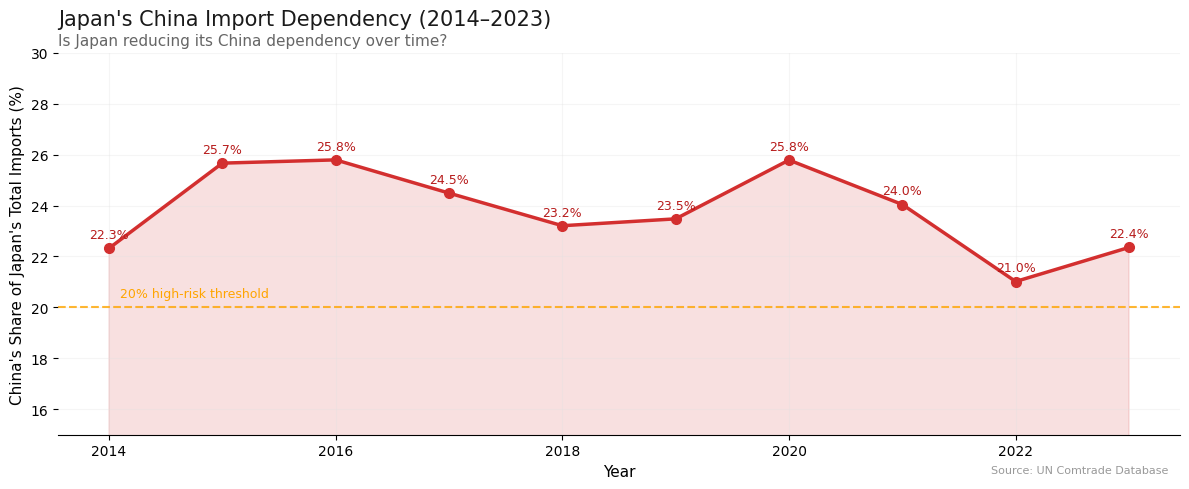

✓ Saved


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')

ax.fill_between(china_dep['year'],
                china_dep['dependency_pct'],
                alpha=0.15, color='#D32F2F')

ax.plot(china_dep['year'],
        china_dep['dependency_pct'],
        color='#D32F2F', linewidth=2.5,
        marker='o', markersize=7)

# Annotate each point
for _, row in china_dep.iterrows():
    ax.text(row['year'],
            row['dependency_pct'] + 0.4,
            f"{row['dependency_pct']:.1f}%",
            ha='center', fontsize=9,
            color='#B71C1C', fontweight='500')

# WHY 20% threshold line:
# Japan's economic security policy considers
# >20% from single supplier as high-risk
# Shows whether Japan is above or below that line
ax.axhline(y=20, color='orange', linestyle='--',
           alpha=0.8, linewidth=1.5)
ax.text(2014.1, 20.4, '20% high-risk threshold',
        fontsize=9, color='orange')

ax.set_title("Japan's China Import Dependency (2014–2023)",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'Is Japan reducing its China dependency over time?',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("China's Share of Japan's Total Imports (%)",
              fontsize=11)
ax.set_ylim(15, 30)
ax.grid(True, alpha=0.3, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/china_dependency_trend.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")